# Light Curve — All Nights
Automatically discovers all night folders for a given target, loads and normalises each subset on the fly, and plots each night as a separate panel.
No pre-merged file required.

In [1]:
TARGET     = '2001_EC'
MAIN_DIR   = '.'          # folder that contains the TARGET subfolder
FILTER     = 'R'          # one of 'B', 'V', 'R', 'I'  — used for magnitude mode

In [2]:
import os, sys, re, glob
import numpy as np
import pandas as pd
from collections import defaultdict
from utils.light_curve import sanity_check, plot_light_curve_all_nights

In [3]:
# ── Locate target directory ────────────────────────────────────────────────────

target_dir = os.path.join(MAIN_DIR)

if not os.path.isdir(target_dir):
    sys.exit(f"Target directory not found:\n  {target_dir}")

# List detected night folders
night_pattern = re.compile(r"^\d{2}_\d{2}_\d{2}(_[a-z])?$")
night_folders = sorted([
    d for d in os.listdir(target_dir)
    if os.path.isdir(os.path.join(target_dir, d)) and night_pattern.match(d)
])

print(f"Target   : {TARGET}")
print(f"Directory: {target_dir}")
print(f"Nights found ({len(night_folders)}): {night_folders}")

Target   : 2001_EC
Directory: .
Nights found (6): ['26_02_27_a', '26_02_27_b', '26_02_28_a', '26_02_28_b', '26_03_01_a', '26_03_01_b']


In [4]:
# ── Sanity check — load one night to verify columns ───────────────────────────
# Reads the first subset of the first night folder without normalising,
# just to confirm expected columns are present.

if night_folders:
    first_night_dir = os.path.join(target_dir, night_folders[0])
    first_subsets   = sorted(glob.glob(os.path.join(first_night_dir, "pipelineout_datasubset.dat")))
    if first_subsets:
        df_check = pd.read_csv(
            first_subsets[0], sep="\t", comment="#",
            names=["index", "Label", "J.D.-2400000", "rel_flux_T1", "rel_flux_err_T1",
                   "AIRMASS", "Source-Sky_T1", "Source_Error_T1"]
        )
        sanity_check(df_check)
    else:
        print(f"No subset files found in {first_night_dir}")
else:
    print("No night folders found — check MAIN_DIR and TARGET.")

J.D.-2400000     : 61099.758157  →  61099.828845
rel_flux_T1      : 0.633565  →  0.756504
Median flux error: 0.012037


  Loaded 26_02_27_a  (217 rows)
  Loaded 26_02_27_b  (248 rows)
  Loaded 26_02_28_a  (180 rows)
  Loaded 26_02_28_b  (176 rows)
  Loaded 26_03_01_a  (240 rows)
  Loaded 26_03_01_b  (253 rows)
  Night 26_02_27: phase overlap [0.00, 1.00], offset = -0.1169
  Night 26_02_28: phase overlap [0.00, 1.00], offset = -0.0691


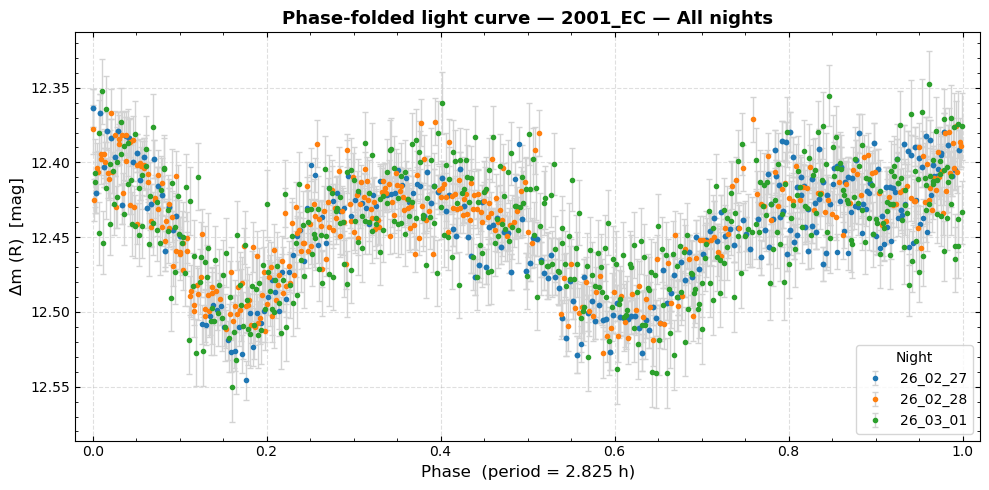

In [5]:
# ── Plot ───────────────────────────────────────────────────────────────────────
MERGE      = True # True → single phase-folded plot; False → one panel per night
MAG_MODE   = True # True → plot in differential magnitude; False → fractional flux
PERIOD     = 5.65/2 # period in hours, or None for raw time axis



plot_light_curve_all_nights(
    TARGET,
    target_dir   = target_dir,
    night_col    = "night",
    # period       = None,
    period       = PERIOD,
    merge_nights = MERGE,
    nb_plot_per_row = 3,
    magnitude    = MAG_MODE,
    filter_name  = FILTER,
    airmass_col  = "AIRMASS",
)